# AFD-CNN Fall Detection on Actigraph Tagged Signals — Both Wrists Mean (2026-03-29)

Variant of the single-wrist notebook: the CNN input signal is the **mean of the Right
Wrist (RW) and Left Wrist (LW)** accelerometer axes (x, y, z) at each timestep.

Pipeline overview:
1. Load raw 64 Hz Actigraph data for RW and LW
2. Compute the two-wrist mean (x, y, z) on the shared timestamp grid
3. Use the tagged windows (`classification_windows_2026_03_29`) to restrict analysis
4. Scan **all tagged timestamps** with a sliding AFD-CNN window
   (200 samples @ 100 Hz = 2 s, step = 25 samples = 0.25 s)
5. Gyroscope half of the 20x20 image is filled by copying the accelerometer data
6. Visualise predictions per task and summarise fall-alert rates

Source data: `/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests/`  
AFD-CNN model: `/home/ubuntu/git/FD-CNN/model/model.ckpt`


## 0. Setup: imports


In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import gcd
from scipy.signal import resample_poly

print('numpy version:', np.__version__)


numpy version: 2.4.4


## 1. Load Actigraph data — RW and LW (2026-03-29 session)


In [2]:
BASE_DIR = Path('/home/ubuntu/git/gait_analysis/Walkin Actigraphs tests')

def load_acti_data(base_dir, fname):
    """
    Load a raw Actigraph CSV file and return a clean DataFrame.
    Skips '#'-prefixed metadata header lines.
    Adds sub-second correction at 64 Hz.
    """
    df = pd.read_csv(base_dir / fname, comment='#', skip_blank_lines=True)
    df.columns = [c.strip() for c in df.columns]

    df['acc_magnitude'] = np.sqrt((df.iloc[:, 2:] ** 2).sum(axis=1))
    df['x'] = df['Accelerometer X']
    df['y'] = df['Accelerometer Y']
    df['z'] = df['Accelerometer Z']

    df['Timestamp UTC'] = pd.to_datetime(df['Timestamp UTC'], utc=True, errors='coerce')

    t0 = df['Timestamp UTC'].dropna().iloc[0]
    df['seconds_elapsed'] = (df['Timestamp UTC'] - t0).dt.total_seconds().astype(float)

    sec_correction = np.arange(len(df)) % 64 / 64.0
    df['seconds_elapsed'] += sec_correction
    df['Timestamp UTC'] += pd.to_timedelta(sec_correction, unit='s')

    return df


df_RW = load_acti_data(BASE_DIR, 'EALS-DATA-004_STM2D48232042_2026-03-29_12_00_00_AM_1.CSV')
df_LW = load_acti_data(BASE_DIR, 'EALS-DATA-002_STM2D48230423_2026-03-29_12_00_00_AM_1.CSV')

for lbl, df in [('RW', df_RW), ('LW', df_LW)]:
    print(f'{lbl}: {len(df):,} samples | '
          f'{df["Timestamp UTC"].iloc[0]} -> {df["Timestamp UTC"].iloc[-1]}')


RW: 10,944,960 samples | 2026-03-29 00:00:00+00:00 -> 2026-03-31 00:46:22.984375+00:00
LW: 11,153,856 samples | 2026-03-29 00:00:00+00:00 -> 2026-03-31 00:24:38.984375+00:00


## 2. Both-wrists mean (x, y, z)

We align RW and LW on the shared timestamp grid (inner join) and average each
accelerometer axis independently.  The resulting signal is used as the CNN input.


In [3]:
df_wrists_mean = df_RW[['Timestamp UTC']].copy()
df_wrists_mean = df_wrists_mean.merge(
    df_RW[['Timestamp UTC', 'x', 'y', 'z', 'acc_magnitude']].rename(columns={
        'x': 'x_RW', 'y': 'y_RW', 'z': 'z_RW', 'acc_magnitude': 'acc_magnitude_RW',
    }),
    on='Timestamp UTC', how='inner',
).merge(
    df_LW[['Timestamp UTC', 'x', 'y', 'z', 'acc_magnitude']].rename(columns={
        'x': 'x_LW', 'y': 'y_LW', 'z': 'z_LW', 'acc_magnitude': 'acc_magnitude_LW',
    }),
    on='Timestamp UTC', how='inner',
)

df_wrists_mean['x'] = (df_wrists_mean['x_RW'] + df_wrists_mean['x_LW']) / 2.0
df_wrists_mean['y'] = (df_wrists_mean['y_RW'] + df_wrists_mean['y_LW']) / 2.0
df_wrists_mean['z'] = (df_wrists_mean['z_RW'] + df_wrists_mean['z_LW']) / 2.0
df_wrists_mean['acc_magnitude'] = np.sqrt(
    df_wrists_mean['x']**2 + df_wrists_mean['y']**2 + df_wrists_mean['z']**2
)
df_wrists_mean = df_wrists_mean[['Timestamp UTC', 'x', 'y', 'z', 'acc_magnitude']]

print(f'Two-wrist mean: {len(df_wrists_mean):,} shared samples')
print(f'Time range: {df_wrists_mean["Timestamp UTC"].iloc[0]} -> '
      f'{df_wrists_mean["Timestamp UTC"].iloc[-1]}')
print(f'Axis ranges -- x: [{df_wrists_mean.x.min():.3f}, {df_wrists_mean.x.max():.3f}] g  '
      f'y: [{df_wrists_mean.y.min():.3f}, {df_wrists_mean.y.max():.3f}] g  '
      f'z: [{df_wrists_mean.z.min():.3f}, {df_wrists_mean.z.max():.3f}] g')


Two-wrist mean: 10,861,504 shared samples
Time range: 2026-03-29 00:00:00+00:00 -> 2026-03-31 00:24:38.984375+00:00
Axis ranges -- x: [-3.014, 5.358] g  y: [-3.960, 4.313] g  z: [-3.769, 3.891] g


## 3. Tagged classification windows


In [4]:
classification_windows_2026_03_29 = [
    ['2026-03-30 20:09:00', '2026-03-30 20:12:00'],  # Put on
    ['2026-03-30 20:13:40', '2026-03-30 20:14:40'],  # RW
    ['2026-03-30 20:14:45', '2026-03-30 20:15:45'],  # LW
    ['2026-03-30 20:15:50', '2026-03-30 20:16:50'],  # RA
    ['2026-03-30 20:17:00', '2026-03-30 20:18:00'],  # LA
    ['2026-03-30 20:18:00', '2026-03-30 20:26:00'],  # In house movement
    ['2026-03-30 20:26:00', '2026-03-30 20:49:00'],  # Biking
    ['2026-03-30 20:49:00', '2026-03-30 20:59:00'],  # In house movement
    ['2026-03-30 21:00:00', '2026-03-30 21:01:30'],  # Walking fast in gym
    ['2026-03-30 21:01:50', '2026-03-30 21:03:50'],  # Running in gym
    ['2026-03-30 21:04:00', '2026-03-30 21:05:30'],  # Elliptic in gym
    ['2026-03-30 21:05:00', '2026-03-30 21:14:00'],  # In house movement
    ['2026-03-30 21:14:00', '2026-03-30 21:38:00'],  # Biking
    ['2026-03-30 21:38:00', '2026-03-30 21:43:00'],  # In house movement
    ['2026-03-30 21:43:40', '2026-03-30 21:44:20'],  # TT
    ['2026-03-30 21:45:00', '2026-03-30 21:47:00'],  # In house movement
    ['2026-03-30 21:47:00', '2026-03-30 22:03:00'],  # PC
    ['2026-03-30 22:03:00', '2026-03-30 22:07:00'],  # In house movement
    ['2026-03-30 22:07:00', '2026-03-30 22:10:00'],  # Put off
]

classification_tasks_2026_03_29 = [
    'Put on', 'RW', 'LW', 'RA', 'LA',
    'In house movement', 'Biking', 'In house movement',
    'Walking fast in gym', 'Running in gym', 'Elliptic in gym',
    'In house movement', 'Biking', 'In house movement',
    'TT', 'In house movement', 'PC', 'In house movement', 'Put off',
]

task_intervals = pd.DataFrame({
    'start_time': [pd.Timestamp(w[0], tz='UTC') for w in classification_windows_2026_03_29],
    'end_time':   [pd.Timestamp(w[1], tz='UTC') for w in classification_windows_2026_03_29],
    'task':       classification_tasks_2026_03_29,
})

SESSION_START = task_intervals['start_time'].min()
SESSION_END   = task_intervals['end_time'].max()
task_order    = list(dict.fromkeys(classification_tasks_2026_03_29))

print(f'Session span: {SESSION_START} -> {SESSION_END}')
print(f'Total tagged windows: {len(task_intervals)}')


Session span: 2026-03-30 20:09:00+00:00 -> 2026-03-30 22:10:00+00:00
Total tagged windows: 19


## 4. Overview plot


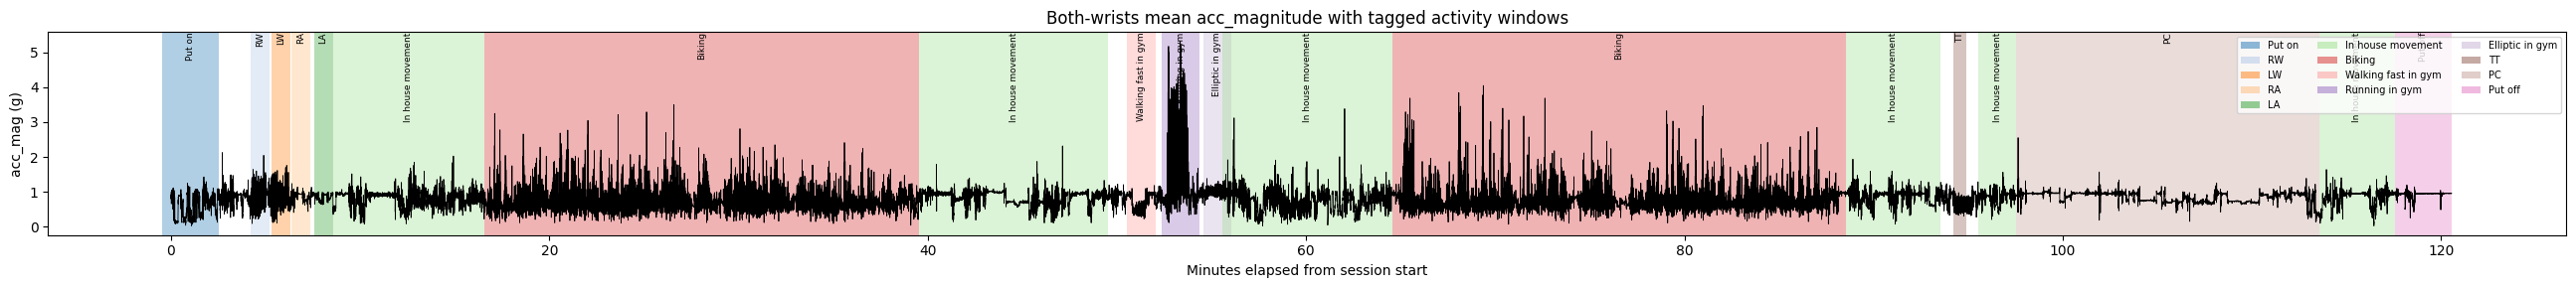

In [5]:
_unique_tasks = list(dict.fromkeys(classification_tasks_2026_03_29))
_palette = list(plt.cm.tab20.colors)
TASK_COLORS = {t: _palette[i % len(_palette)] for i, t in enumerate(_unique_tasks)}

plot_ov = df_wrists_mean[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
plot_ov = plot_ov[
    (plot_ov['Timestamp UTC'] >= SESSION_START) &
    (plot_ov['Timestamp UTC'] <= SESSION_END)
].copy()
t_ref_ov = plot_ov['Timestamp UTC'].iloc[0]
plot_ov['min_elapsed'] = (plot_ov['Timestamp UTC'] - t_ref_ov).dt.total_seconds() / 60.0
if len(plot_ov) > 50_000:
    plot_ov = plot_ov.iloc[::max(1, len(plot_ov) // 50_000)].copy()

fig, ax = plt.subplots(figsize=(26, 3))
for _, row in task_intervals.iterrows():
    s = (row['start_time'] - t_ref_ov).total_seconds() / 60.0
    e = (row['end_time']   - t_ref_ov).total_seconds() / 60.0
    ax.axvspan(s, e, color=TASK_COLORS.get(row['task'], '#cccccc'), alpha=0.35, linewidth=0)
    ax.text((s + e) / 2, 1.0, row['task'],
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=6.5, rotation=90, clip_on=True)
ax.plot(plot_ov['min_elapsed'], plot_ov['acc_magnitude'], color='black', lw=0.6)
ax.set_xlabel('Minutes elapsed from session start')
ax.set_ylabel('acc_mag (g)')
ax.set_title('Both-wrists mean acc_magnitude with tagged activity windows', fontsize=12)
ax.legend(
    handles=[mpatches.Patch(facecolor=TASK_COLORS[t], edgecolor='none', alpha=0.5, label=t)
             for t in _unique_tasks],
    loc='upper right', fontsize=7, ncol=3,
)
plt.tight_layout()
plt.show()


## 5. AFD-CNN setup


In [6]:
import importlib
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
tf.logging.set_verbosity(tf.logging.ERROR)

FD_CNN_SRC   = '/home/ubuntu/git/FD-CNN/src'
FD_CNN_MODEL = '/home/ubuntu/git/FD-CNN/model/model.ckpt'

if FD_CNN_SRC not in sys.path:
    sys.path.insert(0, FD_CNN_SRC)

import cnn as cnn_module
importlib.reload(cnn_module)

FD_CLASS_LIST  = [0, 2, 3, 4, 5, 6, 7, 9]
FD_CLASS_NAMES = {
    0: 'Fall',       2: 'Walk',        3: 'Jog',        4: 'Jump',
    5: 'Up-stairs',  6: 'Down-stairs', 7: 'Stand->Sit', 9: 'Sit->Stand',
}
FD_COLORS = {
    0: '#e84040',  2: '#4a8fd4',  3: '#56b56e',  4: '#e09c30',
    5: '#9b6bd4',  6: '#d47bb5',  7: '#888888',  9: '#aaaaaa',
}

tf.reset_default_graph()
fd_x_ph            = tf.placeholder(tf.float32, [None, 1200], name='fd_input')
fd_logits, fd_keep = cnn_module.fall_net(fd_x_ph)
fd_probs_op        = tf.nn.softmax(fd_logits)

fd_saver = tf.train.Saver()
fd_sess  = tf.Session()
fd_saver.restore(fd_sess, FD_CNN_MODEL)
print('AFD-CNN model restored from', FD_CNN_MODEL)
print('Logits shape:', fd_logits.shape)


I0000 00:00:1776286257.865322  447326 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
non-resource variables are not supported in the long term
AFD-CNN model restored from /home/ubuntu/git/FD-CNN/model/model.ckpt
Logits shape: (?, 8)


E0000 00:00:1776286259.360990  447326 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1776286259.368756  447326 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 6. Sliding-window scanning over ALL tagged timestamps

The two-wrist mean signal (64 Hz) is resampled to 100 Hz.
Each 200-sample window (2 s) is flattened to 600 values (acc half), then duplicated
to fill the gyroscope half, producing the 1200-value input the AFD-CNN expects.


In [7]:
FS_ACTI      = 64    # Actigraph native rate (Hz)
FD_FS_IN     = FS_ACTI
FD_FS_TRAIN  = 100   # AFD-CNN training rate (Hz)
FD_WIN_LEN   = 200   # samples at 100 Hz = 2 s
FD_STEP      = 25    # samples at 100 Hz = 0.25 s


def resolve_time_window(time_window):
    t0 = time_window[0] if isinstance(time_window[0], pd.Timestamp) else pd.Timestamp(time_window[0], tz='UTC')
    tf = time_window[1] if isinstance(time_window[1], pd.Timestamp) else pd.Timestamp(time_window[1], tz='UTC')
    return t0, tf


def resample_bout(arr_g, fs_in, fs_out):
    g = gcd(int(fs_in), int(fs_out))
    return resample_poly(arr_g, int(fs_out) // g, int(fs_in) // g, axis=0).astype(np.float32)


def g_to_uint8(arr_g):
    """Convert g-unit data to [0, 255]: (val*9.81 + 20) * 6, clipped."""
    return np.clip((arr_g * 9.81 + 20.0) * 6.0, 0.0, 255.0).astype(np.float32)


def extract_windows_from_segment(accel_64hz, timestamps_64hz, win_len, step, fs_in, fs_out):
    """
    Resample (N, 3) segment to fs_out Hz, then scan with a sliding window.
    Each window: (win_len, 3) acc -> flatten (600,) -> concatenate with itself
    to produce the (1200,) input (acc top half + acc copy as gyro proxy).
    """
    if len(accel_64hz) == 0:
        return np.empty((0, 1200), dtype=np.float32), []

    scale = fs_out / fs_in
    arr_resampled = resample_bout(accel_64hz, fs_in, fs_out)
    arr_uint8     = g_to_uint8(arr_resampled)

    windows, meta = [], []
    n_resamp = len(arr_resampled)

    for w_idx, off in enumerate(range(0, n_resamp - win_len + 1, step)):
        chunk = arr_uint8[off: off + win_len]          # (200, 3) accelerometer
        flat  = chunk.flatten()                         # (600,)
        windows.append(np.concatenate([flat, flat]))   # (1200,) acc + acc copy as gyro proxy

        s_orig = min(int(off / scale),             len(timestamps_64hz) - 1)
        e_orig = min(int((off + win_len) / scale), len(timestamps_64hz) - 1)
        meta.append(dict(win_idx=w_idx,
                         start_dt=timestamps_64hz[s_orig],
                         end_dt=timestamps_64hz[e_orig]))

    return np.array(windows, dtype=np.float32), meta


print('Sliding-window parameters:')
print(f'  Native rate    : {FD_FS_IN} Hz')
print(f'  Resample to    : {FD_FS_TRAIN} Hz')
print(f'  Window length  : {FD_WIN_LEN} samples = {FD_WIN_LEN/FD_FS_TRAIN:.2f} s')
print(f'  Step           : {FD_STEP} samples = {FD_STEP/FD_FS_TRAIN:.3f} s')
print('  Image layout   : wrists mean acc (rows 0-9) + acc copy as gyro proxy (rows 10-19)')


Sliding-window parameters:
  Native rate    : 64 Hz
  Resample to    : 100 Hz
  Window length  : 200 samples = 2.00 s
  Step           : 25 samples = 0.250 s
  Image layout   : wrists mean acc (rows 0-9) + acc copy as gyro proxy (rows 10-19)


In [8]:
# Scan ALL tagged time windows using the two-wrist mean signal
all_windows = []
all_meta    = []

for (win_str, task) in zip(classification_windows_2026_03_29, classification_tasks_2026_03_29):
    t0, tf = resolve_time_window(win_str)

    seg = df_wrists_mean[
        (df_wrists_mean['Timestamp UTC'] >= t0) &
        (df_wrists_mean['Timestamp UTC'] <= tf)
][['Timestamp UTC', 'x', 'y', 'z']].dropna().copy()

    if seg.empty:
        print(f'  [{task}] -- no data in window, skipping')
        continue

    accel_seg = seg[['x', 'y', 'z']].to_numpy(dtype=np.float32)
    ts_seg    = seg['Timestamp UTC'].to_numpy()

    wins, meta = extract_windows_from_segment(
        accel_seg, ts_seg,
        win_len=FD_WIN_LEN, step=FD_STEP,
        fs_in=FD_FS_IN, fs_out=FD_FS_TRAIN,
    )

    dur_s = (tf - t0).total_seconds()
    print(f'  [{task}]  {len(seg):,} samples ({dur_s:.0f} s)  ->  {len(wins)} windows')

    for m in meta:
        m['task']         = task
        m['win_start_tag'] = t0
        m['win_end_tag']   = tf

    all_windows.append(wins)
    all_meta.extend(meta)

fd_windows = np.vstack(all_windows) if all_windows else np.empty((0, 1200), dtype=np.float32)

print(f'\nTotal windows across all tagged segments: {len(fd_windows)}')
print(f'Input tensor shape : {fd_windows.shape}')
if len(fd_windows):
    print(f'Value range        : [{fd_windows.min():.1f}, {fd_windows.max():.1f}]')


  [Put on]  9,793 samples (180 s)  ->  605 windows
  [RW]  3,841 samples (60 s)  ->  233 windows
  [LW]  3,841 samples (60 s)  ->  233 windows
  [RA]  3,841 samples (60 s)  ->  233 windows
  [LA]  3,841 samples (60 s)  ->  233 windows
  [In house movement]  30,721 samples (480 s)  ->  1913 windows
  [Biking]  88,321 samples (1380 s)  ->  5513 windows
  [In house movement]  38,401 samples (600 s)  ->  2393 windows
  [Walking fast in gym]  5,761 samples (90 s)  ->  353 windows
  [Running in gym]  7,681 samples (120 s)  ->  473 windows
  [Elliptic in gym]  5,761 samples (90 s)  ->  353 windows
  [In house movement]  34,561 samples (540 s)  ->  2153 windows
  [Biking]  92,161 samples (1440 s)  ->  5753 windows
  [In house movement]  19,201 samples (300 s)  ->  1193 windows
  [TT]  2,561 samples (40 s)  ->  153 windows
  [In house movement]  7,681 samples (120 s)  ->  473 windows
  [PC]  61,441 samples (960 s)  ->  3833 windows
  [In house movement]  15,361 samples (240 s)  ->  953 windows


In [9]:
# Run all windows through AFD-CNN in batches
BATCH_SIZE = 512

if len(fd_windows) == 0:
    print('No windows to classify.')
else:
    fd_probs_list = []
    for start in range(0, len(fd_windows), BATCH_SIZE):
        batch = fd_windows[start: start + BATCH_SIZE]
        probs = fd_sess.run(fd_probs_op, feed_dict={fd_x_ph: batch, fd_keep: 1.0})
        fd_probs_list.append(probs)

    fd_probs       = np.vstack(fd_probs_list)
    fd_pred_idx    = np.argmax(fd_probs, axis=1)
    fd_pred_labels = [FD_CLASS_LIST[i]  for i in fd_pred_idx]
    fd_pred_names  = [FD_CLASS_NAMES[l] for l in fd_pred_labels]
    fd_fall_probs  = fd_probs[:, FD_CLASS_LIST.index(0)]

    fd_results = pd.DataFrame(all_meta)
    fd_results['pred_label'] = fd_pred_labels
    fd_results['pred_name']  = fd_pred_names
    fd_results['fall_prob']  = fd_fall_probs
    fd_results['max_prob']   = fd_probs.max(axis=1)
    fd_results['start_dt']   = pd.to_datetime(fd_results['start_dt'], utc=True)
    fd_results['end_dt']     = pd.to_datetime(fd_results['end_dt'],   utc=True)

    n_fall = (fd_results['pred_label'] == 0).sum()
    print(f'AFD-CNN results: {len(fd_results)} windows total')
    print(f'  Fall alerts : {n_fall} / {len(fd_results)} ({n_fall/len(fd_results):.1%})')
    print()
    print('Predicted class distribution across all tagged windows:')
    print(fd_results['pred_name'].value_counts().to_string())


AFD-CNN results: 27759 windows total
  Fall alerts : 636 / 27759 (2.3%)

Predicted class distribution across all tagged windows:
pred_name
Down-stairs    26761
Fall             636
Jog              302
Up-stairs         58
Walk               1
Sit->Stand         1


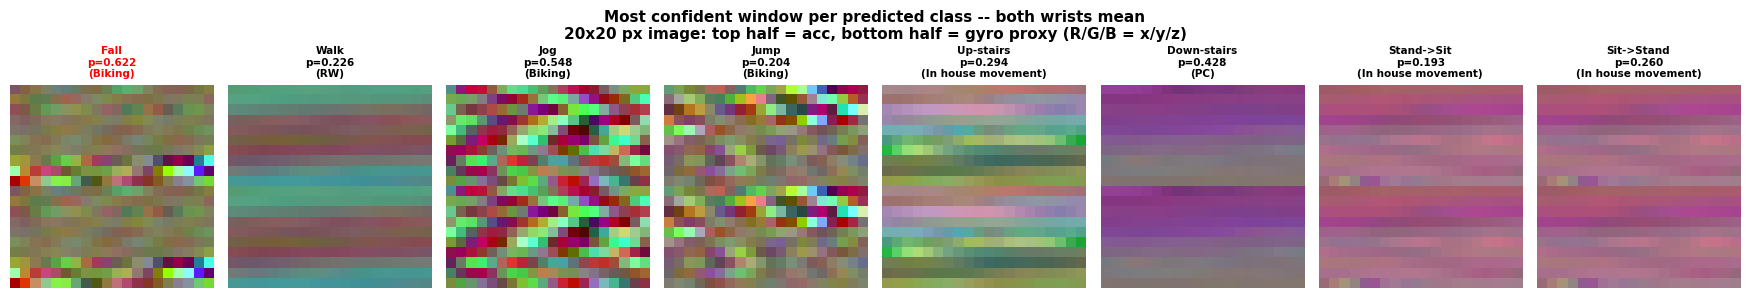

In [10]:
# Best-detected window per predicted class (20x20 RGB image, one per class)
# Top half = wrists mean acc; bottom half = acc copy (gyro proxy)

def to_image_acti(window_values):
    img = np.array(window_values, dtype=np.float32).reshape(20, 20, 3)
    return img / 255.0

n_cl = len(FD_CLASS_LIST)
fig, axes = plt.subplots(1, n_cl, figsize=(2.2 * n_cl, 3.2))

for ax, label in zip(axes, FD_CLASS_LIST):
    cls_idx   = FD_CLASS_LIST.index(label)
    best_idx  = int(np.argmax(fd_probs[:, cls_idx]))
    best_prob = fd_probs[best_idx, cls_idx]
    best_task = fd_results.iloc[best_idx]['task']

    ax.imshow(to_image_acti(fd_windows[best_idx]))
    color = 'red' if label == 0 else 'black'
    ax.set_title(f'{FD_CLASS_NAMES[label]}\np={best_prob:.3f}\n({best_task})',
                 fontsize=7.5, color=color, fontweight='bold')
    ax.axis('off')
    if label == 0:
        for spine in ax.spines.values():
            spine.set_edgecolor('red')
            spine.set_linewidth(2)

fig.suptitle(
    'Most confident window per predicted class -- both wrists mean\n'
    '20x20 px image: top half = acc, bottom half = gyro proxy (R/G/B = x/y/z)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()


## 7. Results — per-task summary


In [11]:
if len(fd_results) > 0:
    task_summary = (
        fd_results
        .groupby('task')
        .agg(
            n_windows=('pred_name', 'count'),
            fall_alerts=('pred_label', lambda x: (x == 0).sum()),
            mean_fall_prob=('fall_prob', 'mean'),
            max_fall_prob=('fall_prob', 'max'),
            top_class=('pred_name', lambda x: x.mode()[0]),
        )
        .reset_index()
    )
    task_summary['fall_alert_rate'] = task_summary['fall_alerts'] / task_summary['n_windows']
    task_summary['_order'] = task_summary['task'].map({t: i for i, t in enumerate(task_order)})
    task_summary = task_summary.sort_values('_order').drop(columns='_order')

    print('=== Per-task AFD-CNN summary (both wrists mean) ===')
    print(task_summary.to_string(index=False, float_format='{:.3f}'.format))


=== Per-task AFD-CNN summary (both wrists mean) ===
               task  n_windows  fall_alerts  mean_fall_prob  max_fall_prob   top_class  fall_alert_rate
             Put on        605           26           0.117          0.406 Down-stairs            0.043
                 RW        233            0           0.106          0.196 Down-stairs            0.000
                 LW        233            0           0.101          0.166 Down-stairs            0.000
                 RA        233            0           0.103          0.141 Down-stairs            0.000
                 LA        233            0           0.103          0.140 Down-stairs            0.000
  In house movement       9078           44           0.103          0.514 Down-stairs            0.005
             Biking      11266           65           0.140          0.622 Down-stairs            0.006
Walking fast in gym        353            0           0.094          0.144 Down-stairs            0.000
     Running

## 8. Visualisation


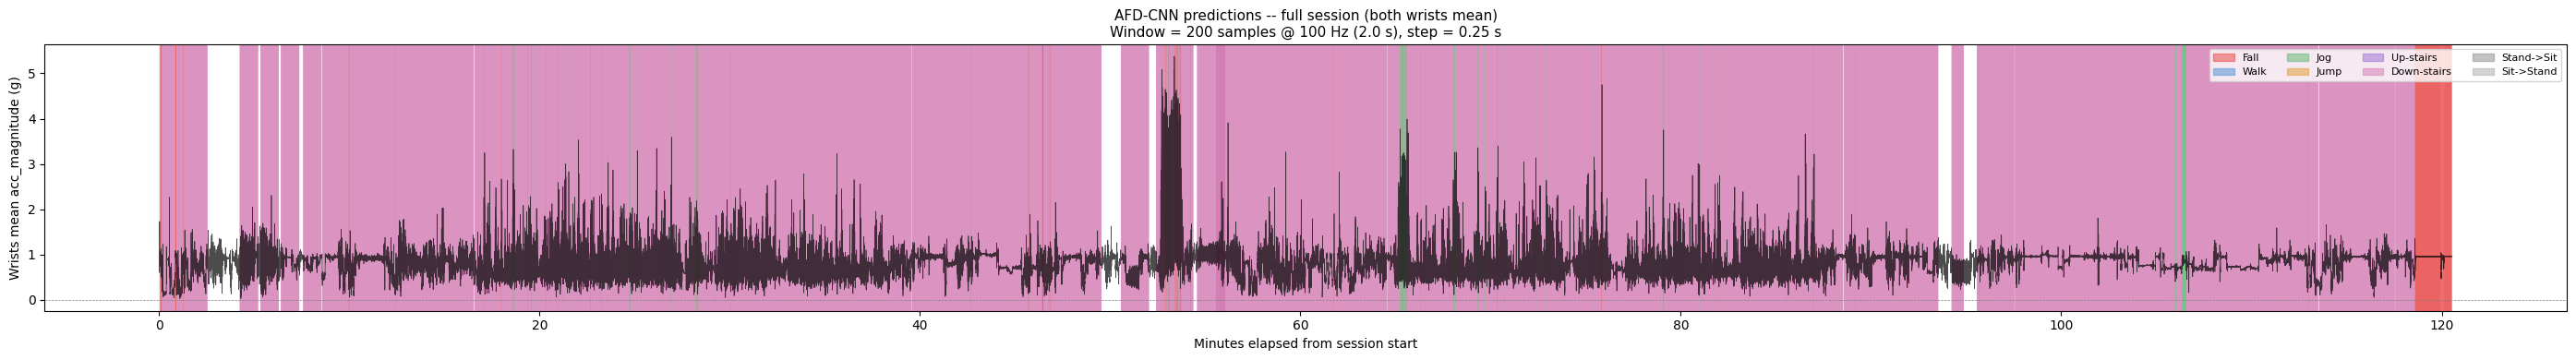

In [12]:
if len(fd_results) > 0:
    plot_sig = df_wrists_mean[['Timestamp UTC', 'acc_magnitude']].dropna().copy()
    plot_sig = plot_sig[
        (plot_sig['Timestamp UTC'] >= SESSION_START) &
        (plot_sig['Timestamp UTC'] <= SESSION_END)
    ].copy()
    t_ref_sig = plot_sig['Timestamp UTC'].iloc[0]
    plot_sig['min_elapsed'] = (plot_sig['Timestamp UTC'] - t_ref_sig).dt.total_seconds() / 60.0
    if len(plot_sig) > 80_000:
        plot_sig = plot_sig.iloc[::max(1, len(plot_sig) // 80_000)].copy()

    fig, ax = plt.subplots(figsize=(28, 4))
    ax.plot(plot_sig['min_elapsed'], plot_sig['acc_magnitude'], color='black', lw=0.5, alpha=0.7)

    for _, row in fd_results.iterrows():
        s = (row['start_dt'] - t_ref_sig).total_seconds() / 60.0
        e = (row['end_dt']   - t_ref_sig).total_seconds() / 60.0
        ax.axvspan(s, e, color=FD_COLORS.get(row['pred_label'], '#cccccc'), alpha=0.18, linewidth=0)

    ax.axhline(0, color='0.5', ls='--', lw=0.5)
    ax.set_xlabel('Minutes elapsed from session start')
    ax.set_ylabel('Wrists mean acc_magnitude (g)')
    ax.set_title(
        f'AFD-CNN predictions -- full session (both wrists mean)\n'
        f'Window = {FD_WIN_LEN} samples @ {FD_FS_TRAIN} Hz ({FD_WIN_LEN/FD_FS_TRAIN:.1f} s), '
        f'step = {FD_STEP/FD_FS_TRAIN:.2f} s',
        fontsize=11,
    )
    ax.legend(
        handles=[mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
                 for l in FD_CLASS_LIST],
        fontsize=8, loc='upper right', ncol=4, framealpha=0.8,
    )
    plt.tight_layout()
    plt.show()


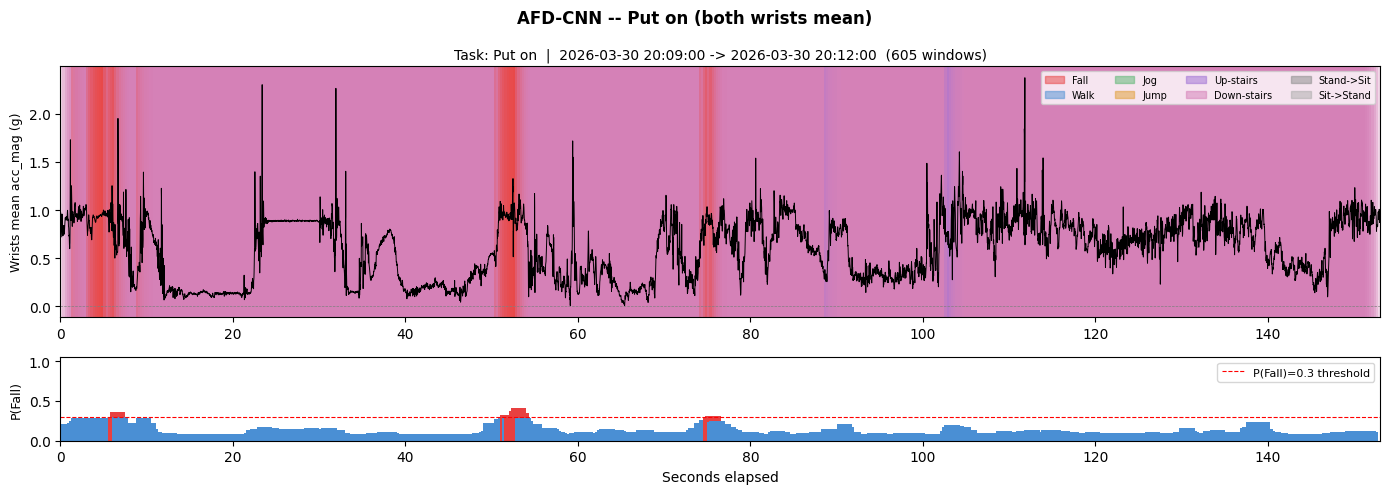

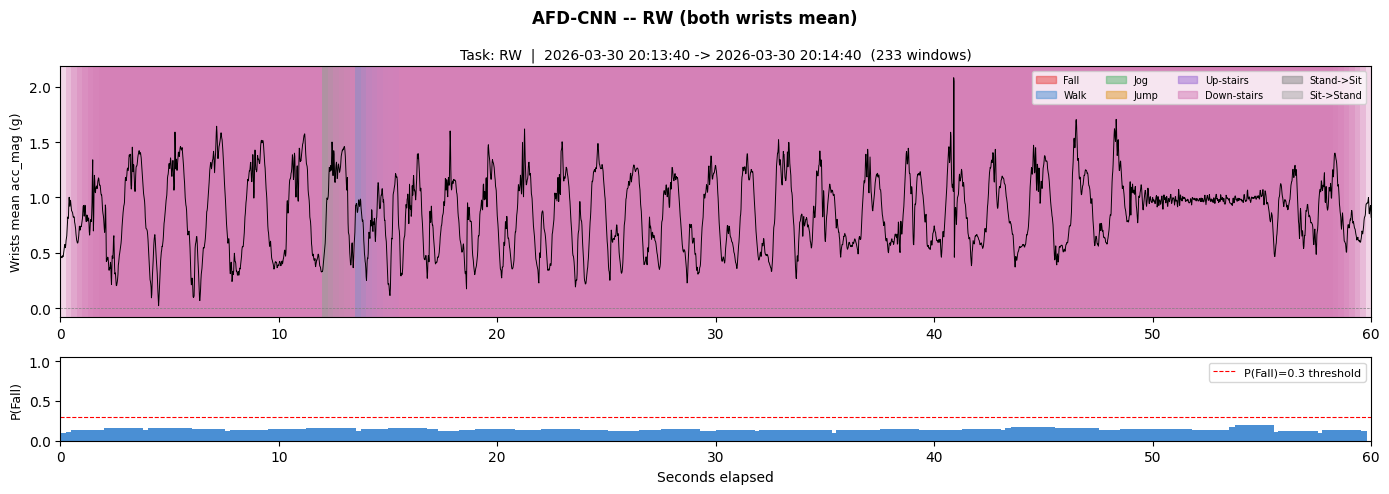

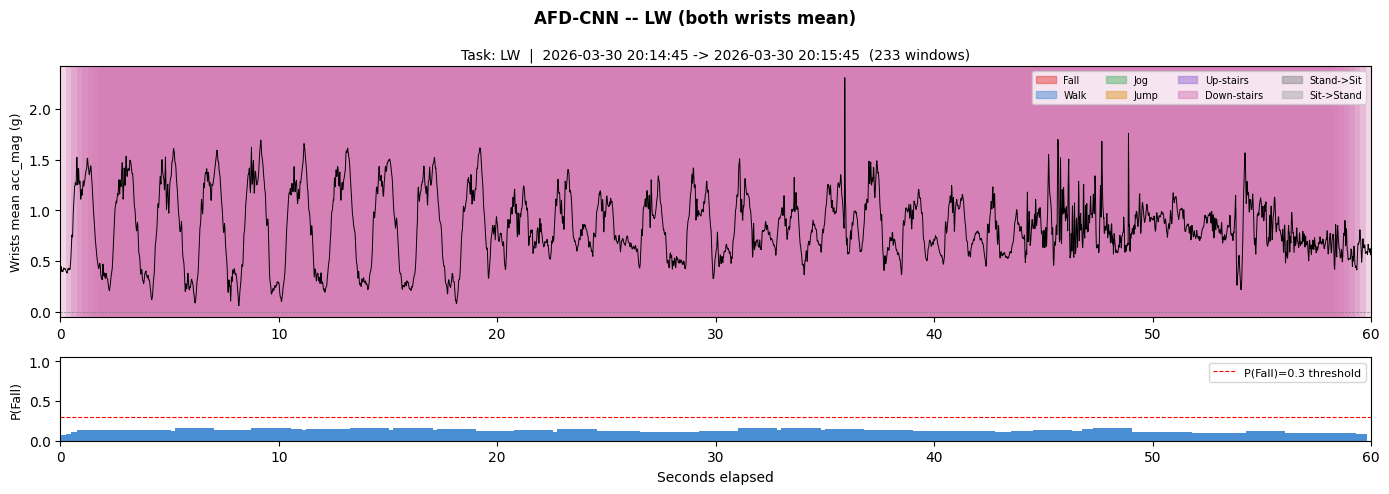

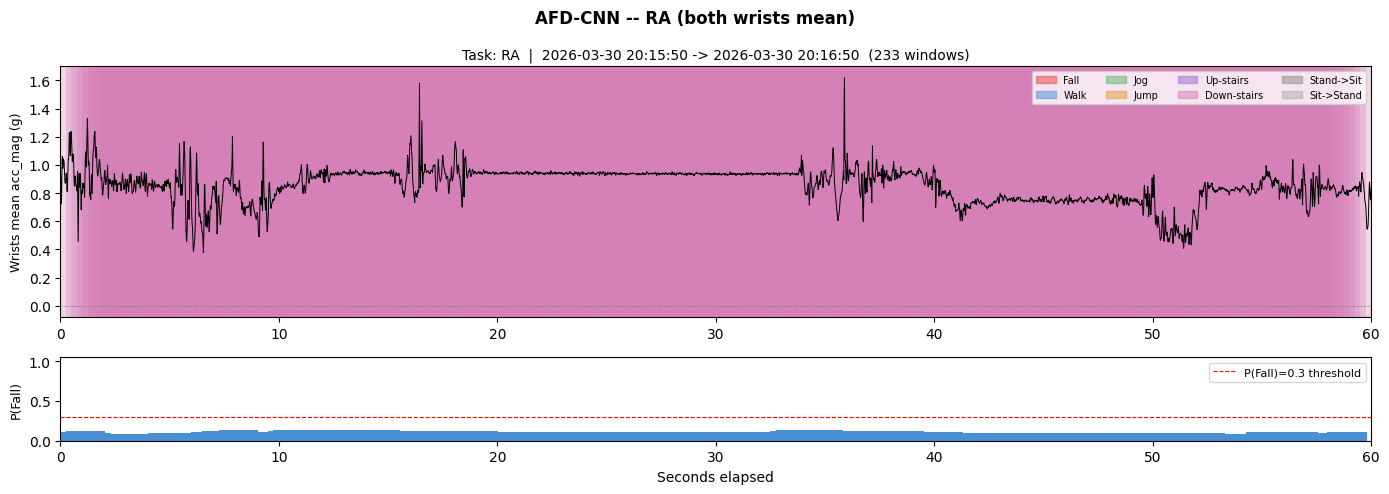

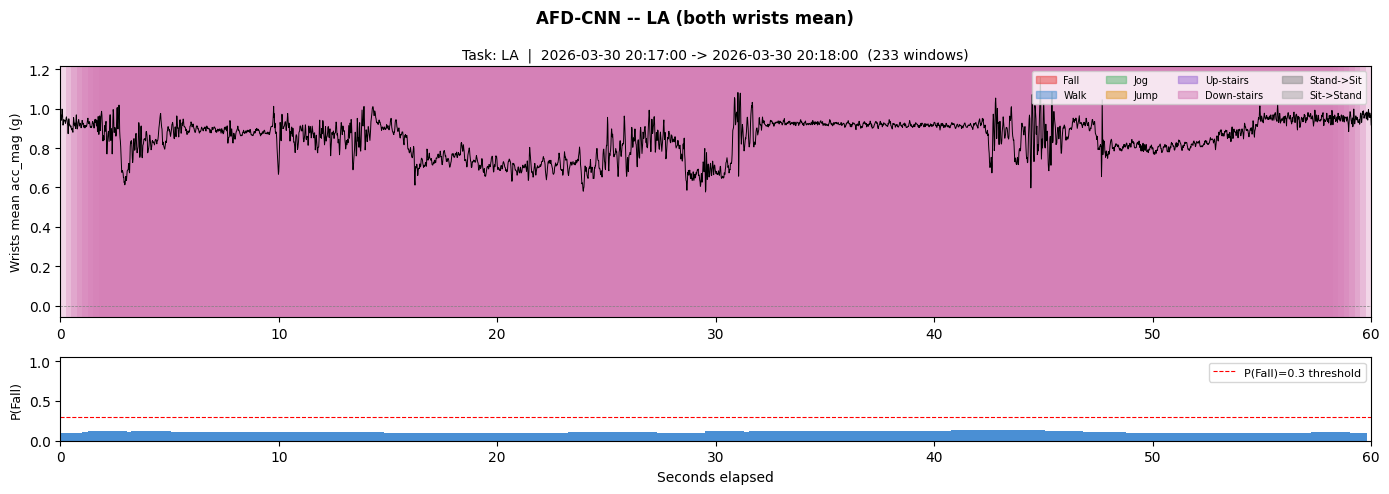

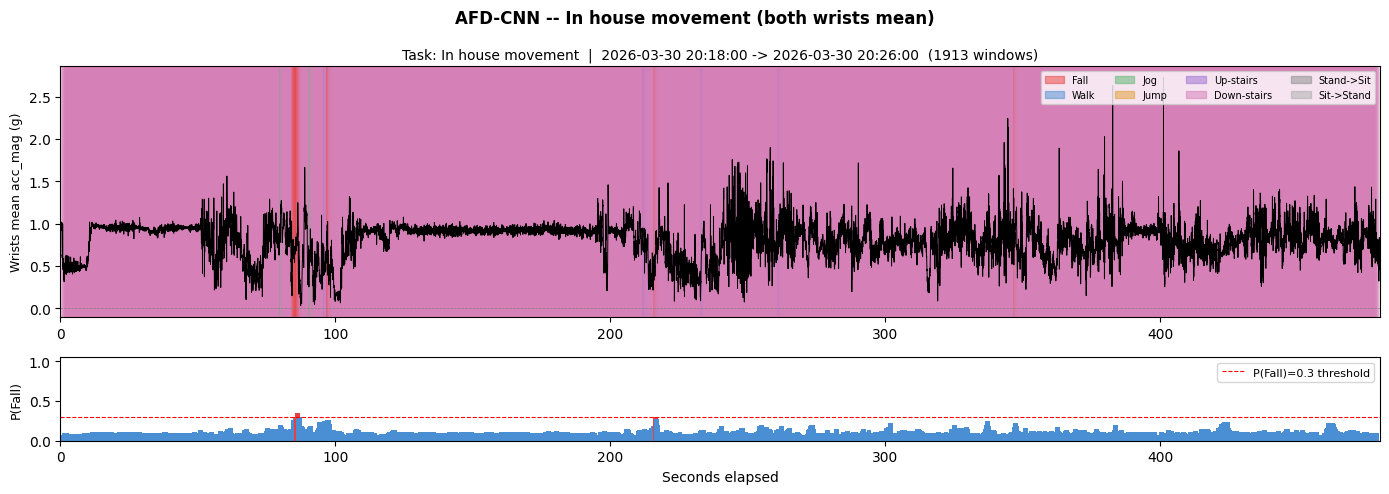

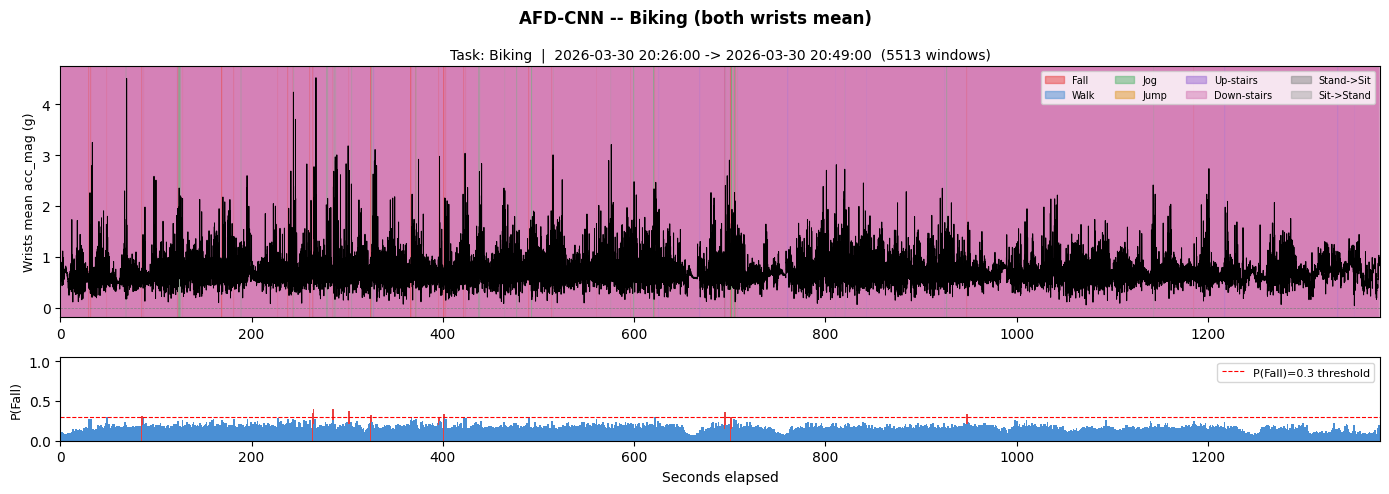

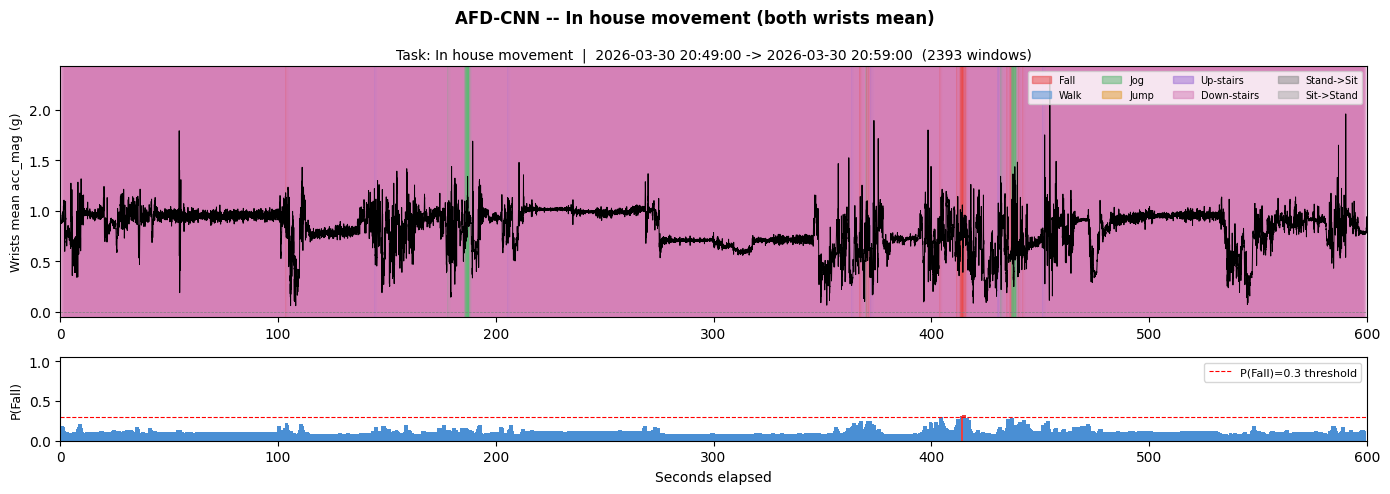

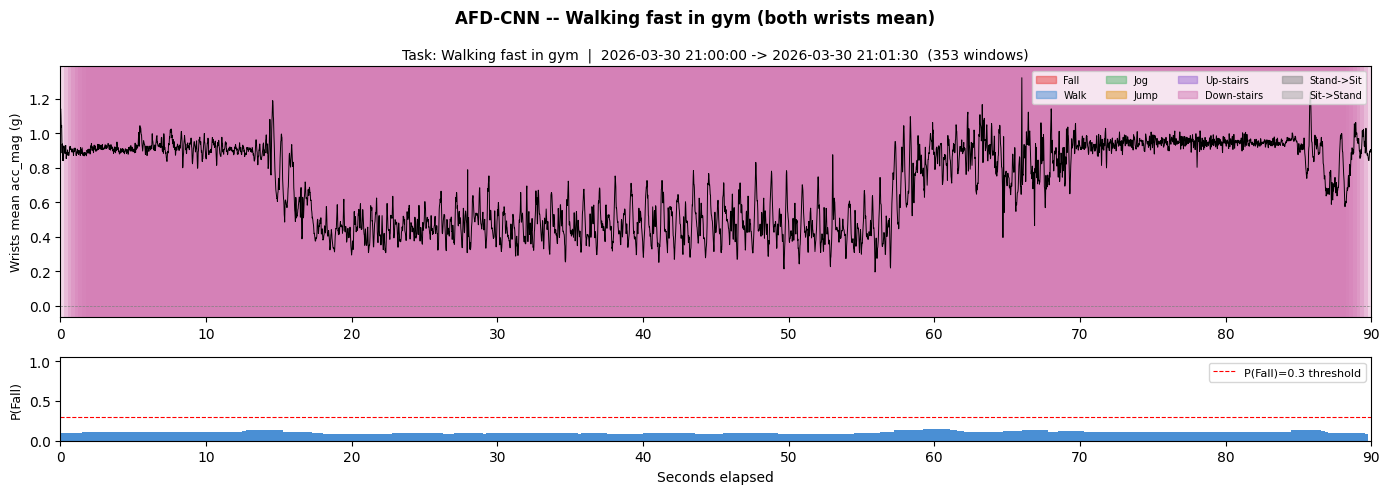

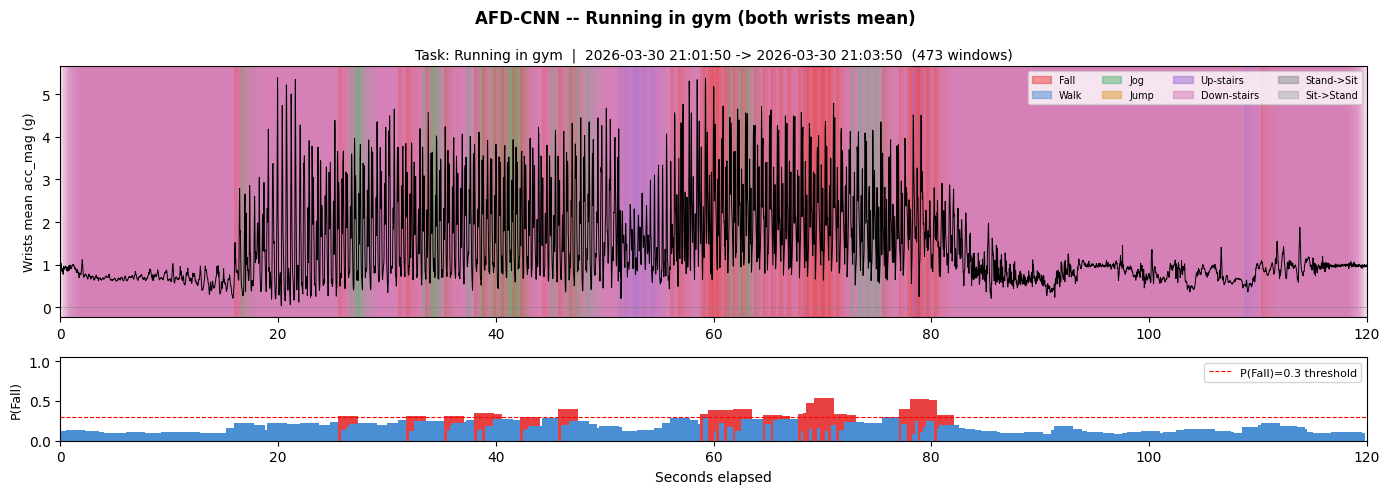

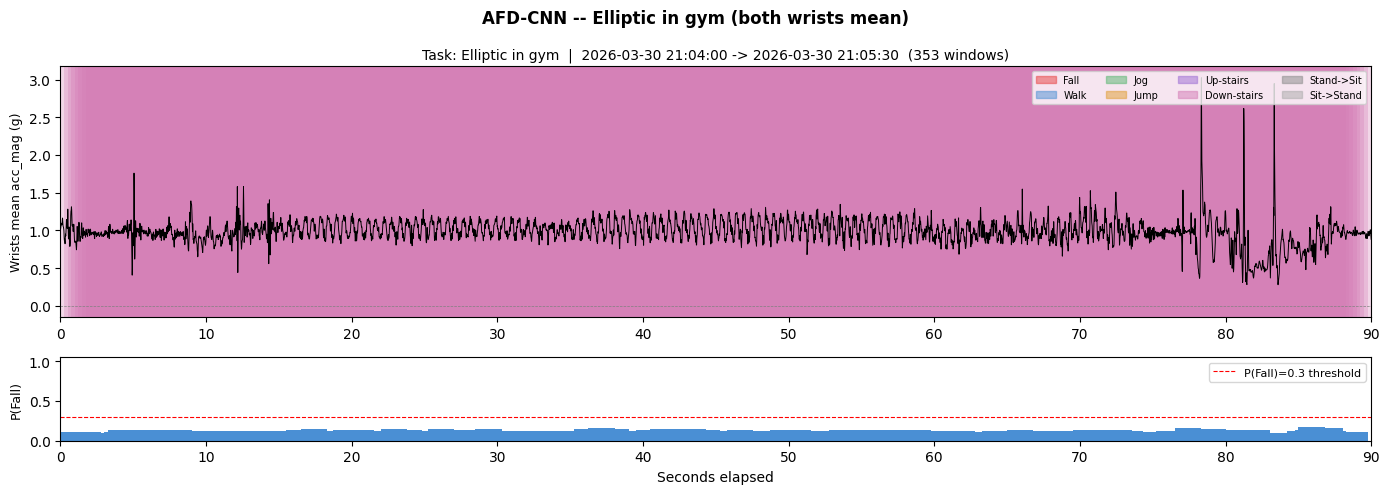

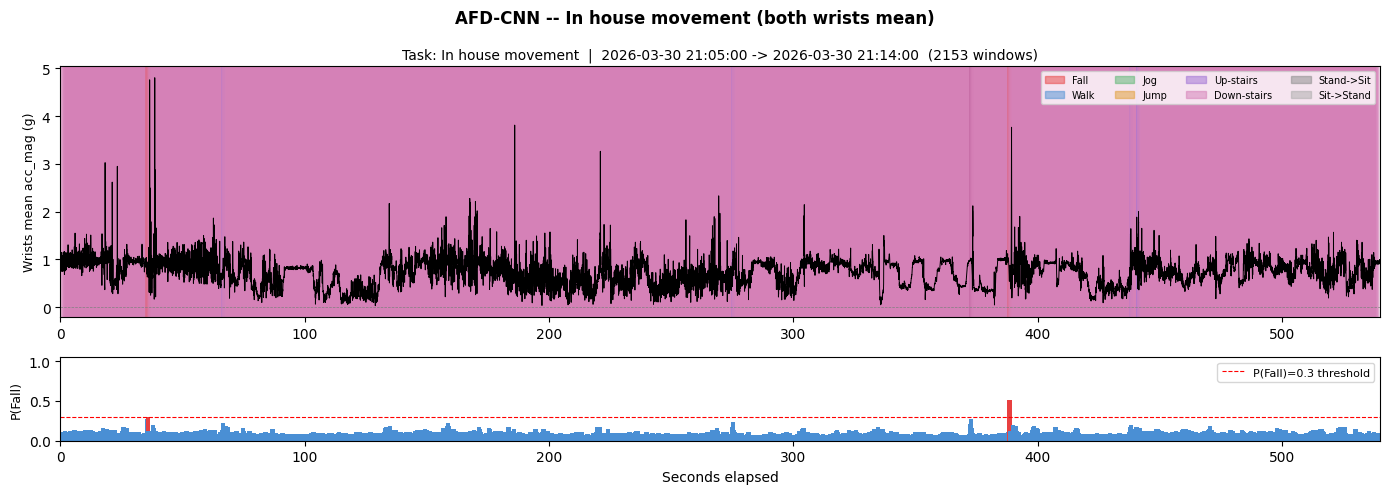

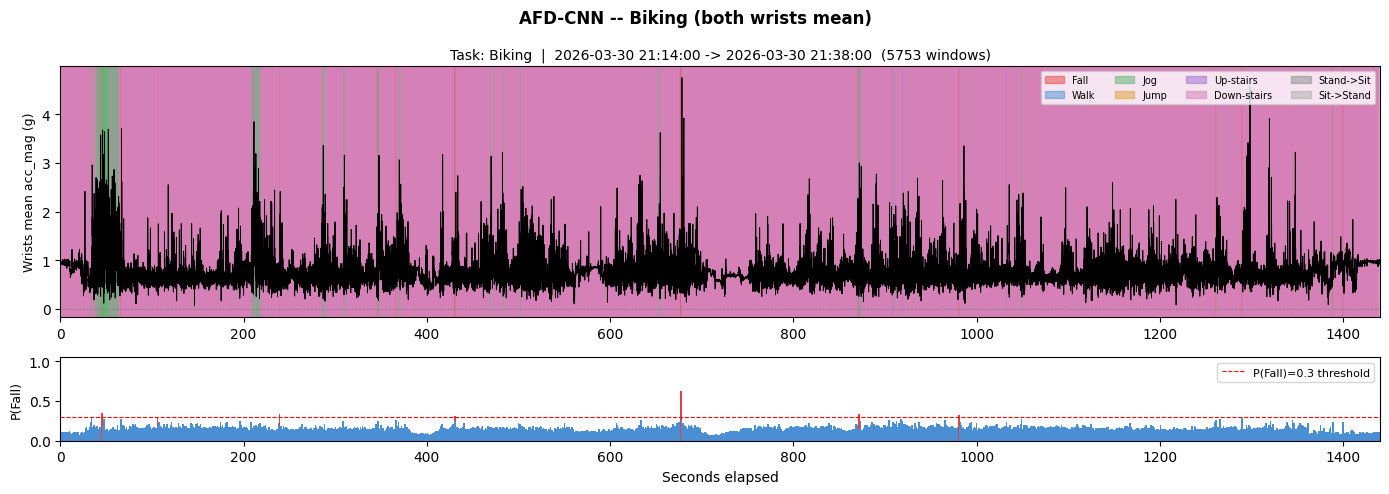

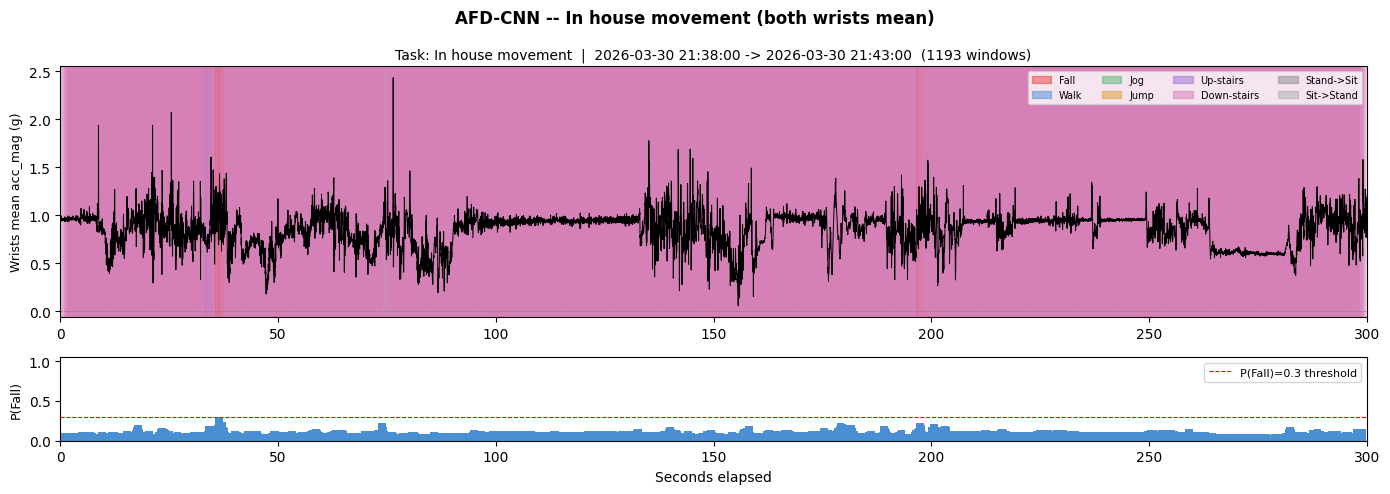

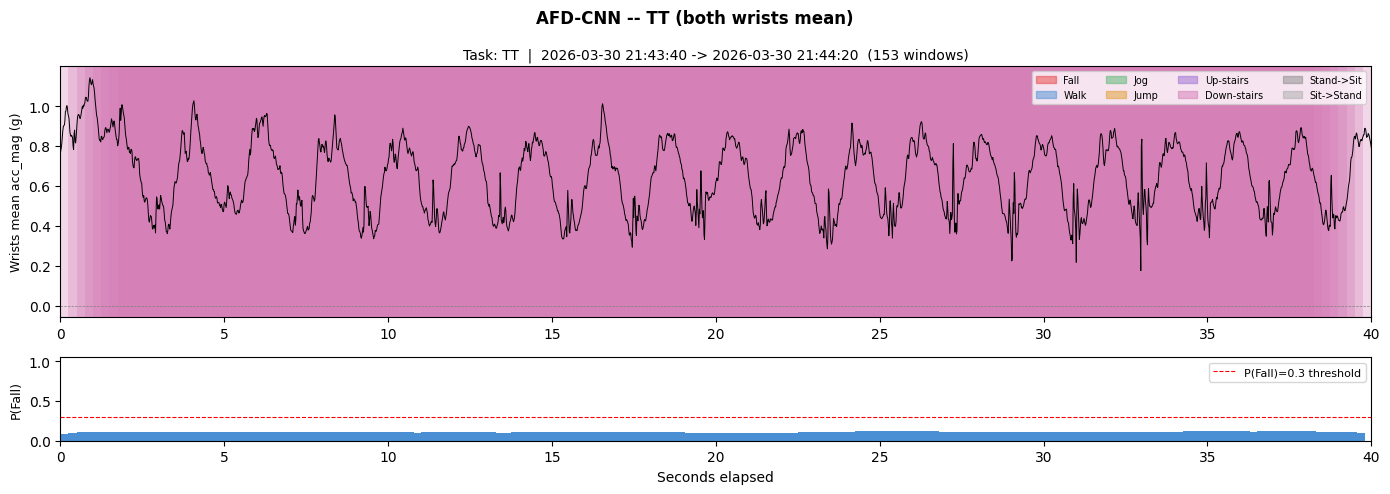

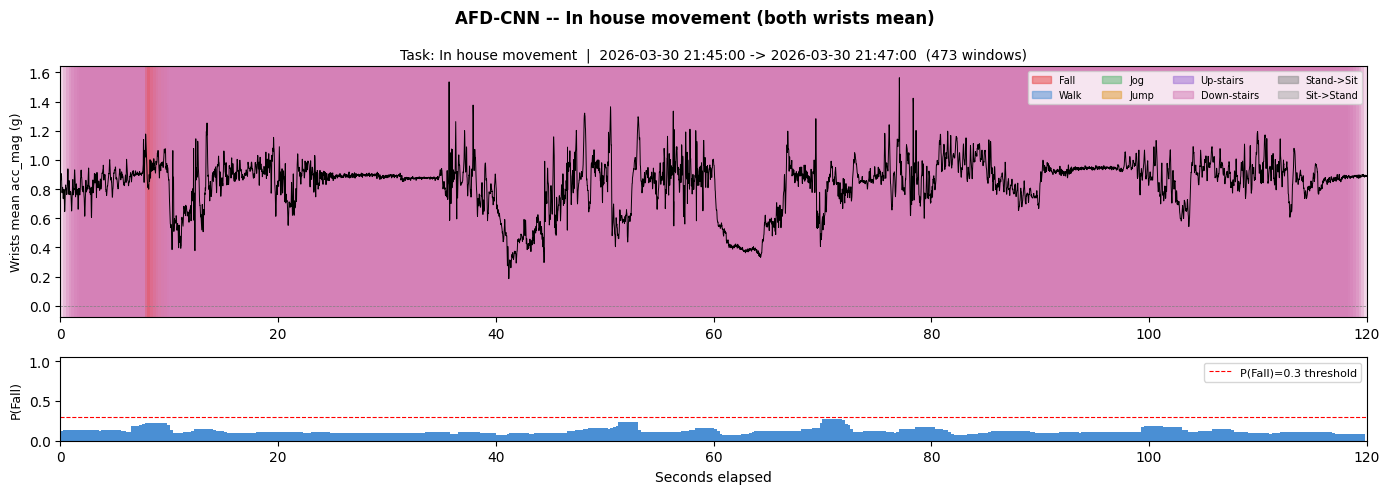

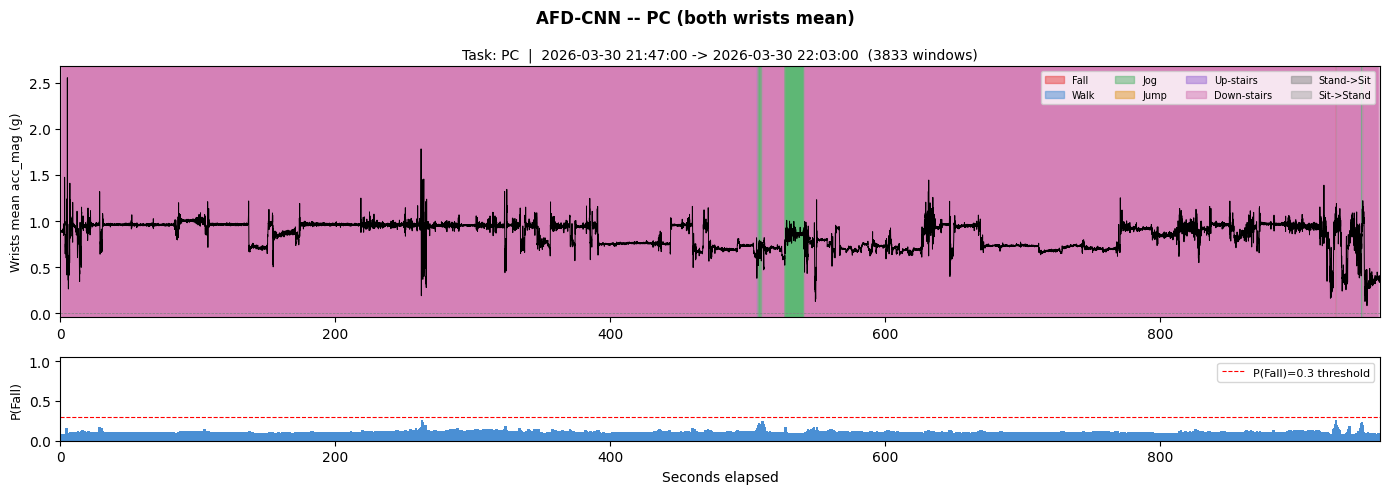

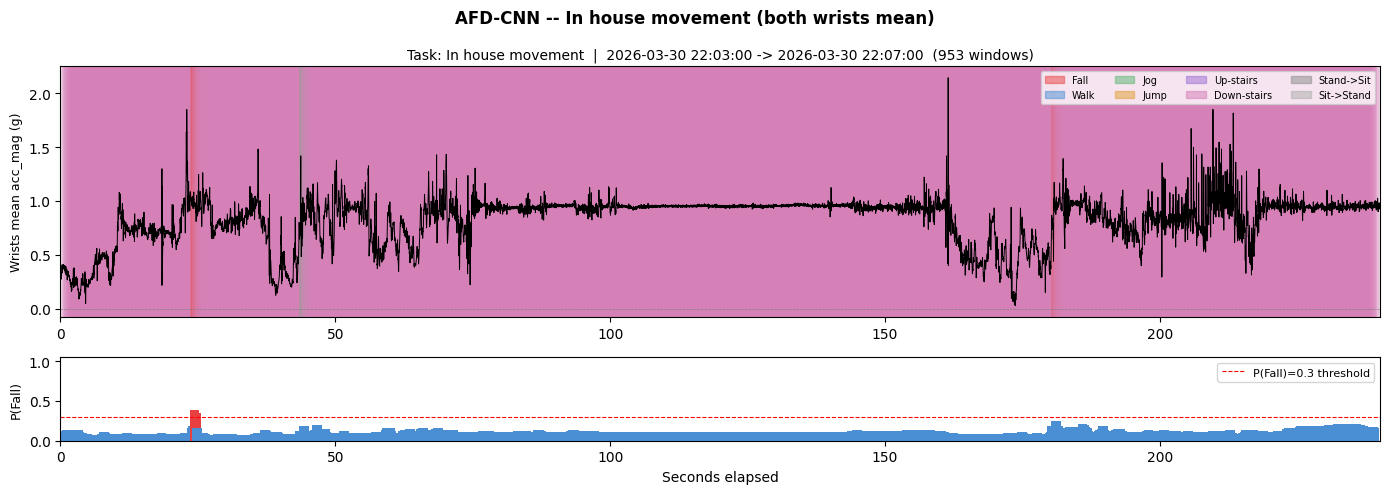

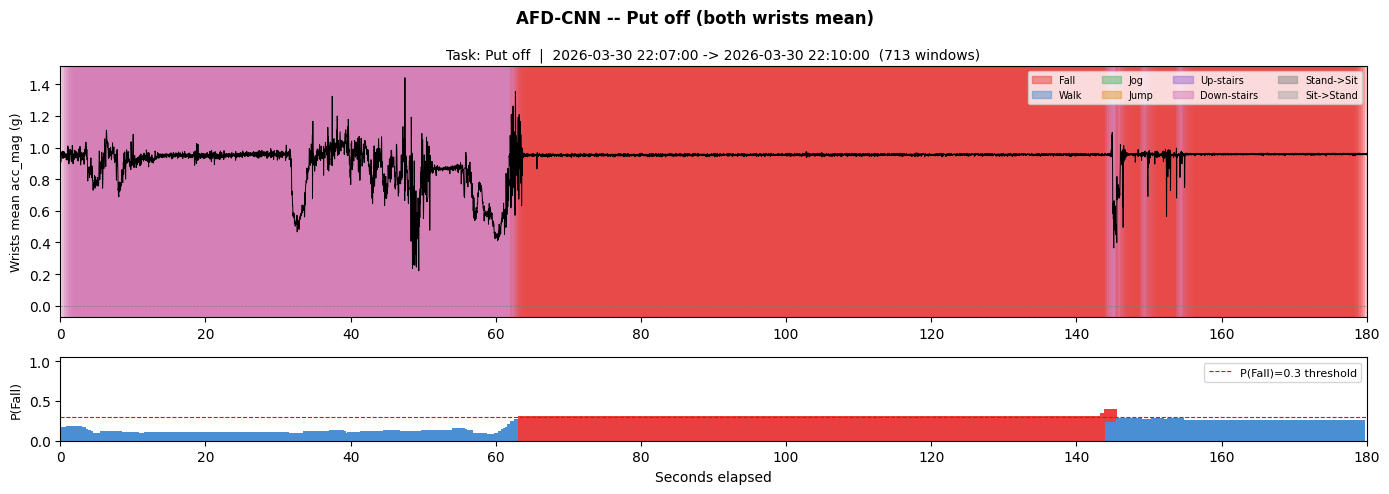

In [13]:
if len(fd_results) > 0:
    for (win_str, task) in zip(classification_windows_2026_03_29, classification_tasks_2026_03_29):
        t0_z, tf_z = resolve_time_window(win_str)

        task_wins = fd_results[
            (fd_results['task'] == task) &
            (fd_results['start_dt'] >= t0_z) &
            (fd_results['end_dt']   <= tf_z)
        ].copy()
        if task_wins.empty:
            continue

        seg_sig = df_wrists_mean[
            (df_wrists_mean['Timestamp UTC'] >= t0_z) &
            (df_wrists_mean['Timestamp UTC'] <= tf_z)
        ][['Timestamp UTC', 'acc_magnitude']].dropna().copy()
        if seg_sig.empty:
            continue

        t_ref_z = seg_sig['Timestamp UTC'].iloc[0]
        seg_sig['sec_elapsed'] = (seg_sig['Timestamp UTC'] - t_ref_z).dt.total_seconds()
        if len(seg_sig) > 20_000:
            seg_sig = seg_sig.iloc[::max(1, len(seg_sig) // 20_000)].copy()

        fig, (ax_sig, ax_fall) = plt.subplots(
            2, 1, figsize=(14, 5), gridspec_kw={'height_ratios': [3, 1]},
        )

        ax_sig.plot(seg_sig['sec_elapsed'], seg_sig['acc_magnitude'], color='black', lw=0.7)
        for _, row in task_wins.iterrows():
            s = (row['start_dt'] - t_ref_z).total_seconds()
            e = (row['end_dt']   - t_ref_z).total_seconds()
            ax_sig.axvspan(s, e, color=FD_COLORS.get(row['pred_label'], '#cccccc'),
                           alpha=0.30, linewidth=0)
        ax_sig.axhline(0, color='0.5', ls='--', lw=0.5)
        ax_sig.set_ylabel('Wrists mean acc_mag (g)', fontsize=9)
        ax_sig.set_title(
            f'Task: {task}  |  {win_str[0]} -> {win_str[1]}  ({len(task_wins)} windows)',
            fontsize=10,
        )
        ax_sig.legend(
            handles=[mpatches.Patch(color=FD_COLORS[l], alpha=0.5, label=FD_CLASS_NAMES[l])
                     for l in FD_CLASS_LIST],
            fontsize=7, loc='upper right', ncol=4, framealpha=0.8,
        )

        x_sec = [(row['start_dt'] - t_ref_z).total_seconds() for _, row in task_wins.iterrows()]
        colors_bar = ['#e84040' if p >= 0.3 else '#4a8fd4' for p in task_wins['fall_prob']]
        ax_fall.bar(x_sec, task_wins['fall_prob'],
                    width=FD_WIN_LEN / FD_FS_TRAIN * 0.9,
                    color=colors_bar, edgecolor='none', align='edge')
        ax_fall.axhline(0.3, color='red', ls='--', lw=0.8, label='P(Fall)=0.3 threshold')
        ax_fall.set_ylim(0, 1.05)
        ax_fall.set_ylabel('P(Fall)', fontsize=9)
        ax_fall.set_xlabel('Seconds elapsed')
        ax_fall.legend(fontsize=8, loc='upper right')

        x_min = seg_sig['sec_elapsed'].iloc[0]
        x_max = seg_sig['sec_elapsed'].iloc[-1]
        ax_sig.set_xlim(x_min, x_max)
        ax_fall.set_xlim(x_min, x_max)

        fig.suptitle(f'AFD-CNN -- {task} (both wrists mean)', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


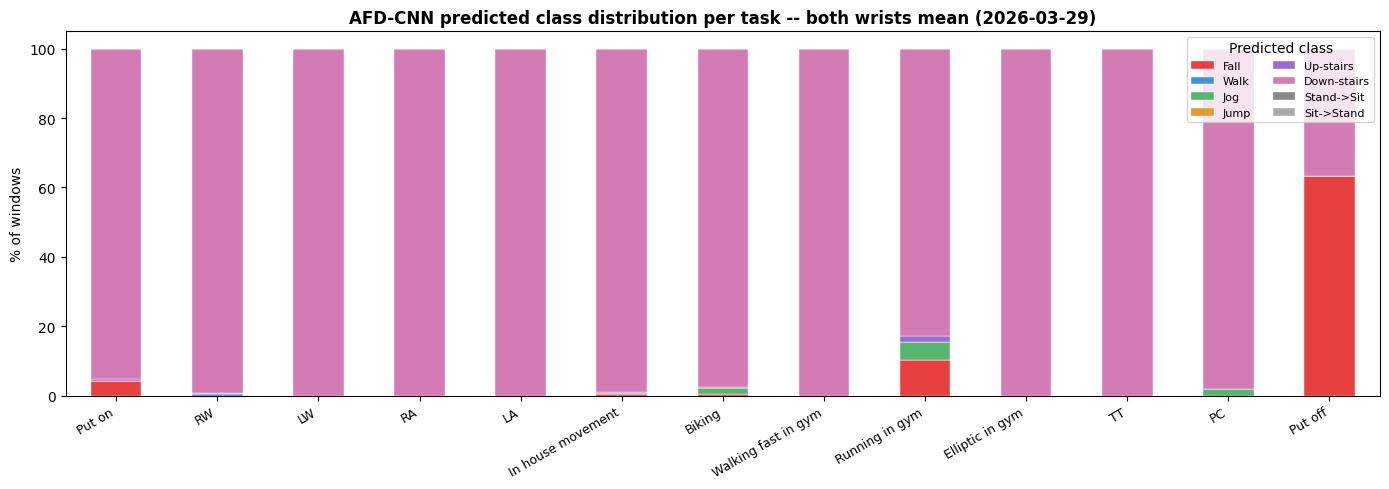


=== Predicted class distribution per task (window counts) ===
pred_name            Fall  Walk  Jog  Jump  Up-stairs  Down-stairs  Stand->Sit  Sit->Stand
task                                                                                      
Put on                 26     0    0     0          3          576           0           0
RW                      0     1    1     0          0          231           0           0
LW                      0     0    0     0          0          233           0           0
RA                      0     0    0     0          0          233           0           0
LA                      0     0    0     0          0          233           0           0
In house movement      44     0   22     0         18         8993           0           1
Biking                 65     0  184     0         27        10990           0           0
Walking fast in gym     0     0    0     0          0          353           0           0
Running in gym         48  

In [14]:
if len(fd_results) > 0:
    _class_order = [FD_CLASS_NAMES[l] for l in FD_CLASS_LIST]
    _counts = (
        fd_results
        .groupby(['task', 'pred_name'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=_class_order, fill_value=0)
    )
    _counts = _counts.reindex([t for t in task_order if t in _counts.index])
    _pct    = _counts.div(_counts.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 5))
    _pct.plot(kind='bar', stacked=True, ax=ax,
              color=[FD_COLORS[l] for l in FD_CLASS_LIST],
              edgecolor='white', linewidth=0.3)
    ax.set_ylabel('% of windows', fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(_pct.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(title='Predicted class', fontsize=8, loc='upper right', ncol=2)
    ax.set_title(
        'AFD-CNN predicted class distribution per task -- both wrists mean (2026-03-29)',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Predicted class distribution per task (window counts) ===')
    print(_counts.to_string())


In [15]:
fd_sess.close()
print('TF session closed.')


TF session closed.
